In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All libraries are working!")

All libraries are working!


In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 6607
Number of Columns: 20


In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
print("Features in the dataset:")

for column in df.columns:
    print("-", column)

Features in the dataset:
- Hours_Studied
- Attendance
- Parental_Involvement
- Access_to_Resources
- Extracurricular_Activities
- Sleep_Hours
- Previous_Scores
- Motivation_Level
- Internet_Access
- Tutoring_Sessions
- Family_Income
- Teacher_Quality
- School_Type
- Peer_Influence
- Physical_Activity
- Learning_Disabilities
- Parental_Education_Level
- Distance_from_Home
- Gender
- Exam_Score


In [6]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.dtypes

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object

In [9]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [10]:
df = df.drop_duplicates()

print("Duplicates removed.")
print("New dataset shape:", df.shape)

Duplicates removed.
New dataset shape: (6607, 20)


In [11]:
# Numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Fill numerical missing values with median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values with mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


C:\Users\Harini\AppData\Local\Temp\ipykernel_8136\3384616053.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [12]:
print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


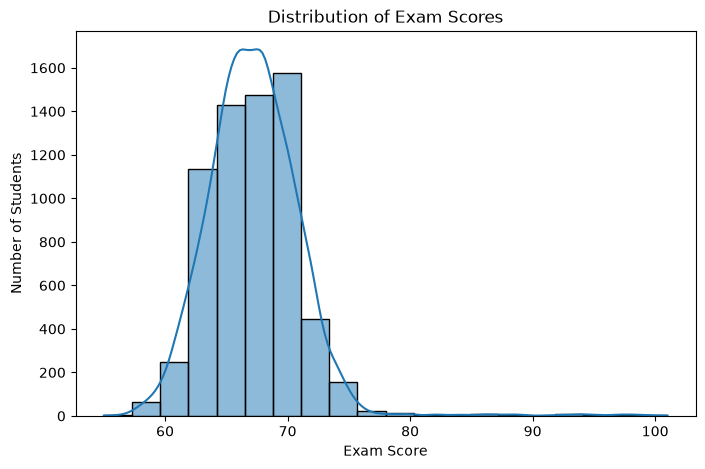

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Exam_Score"], bins=20, kde=True)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

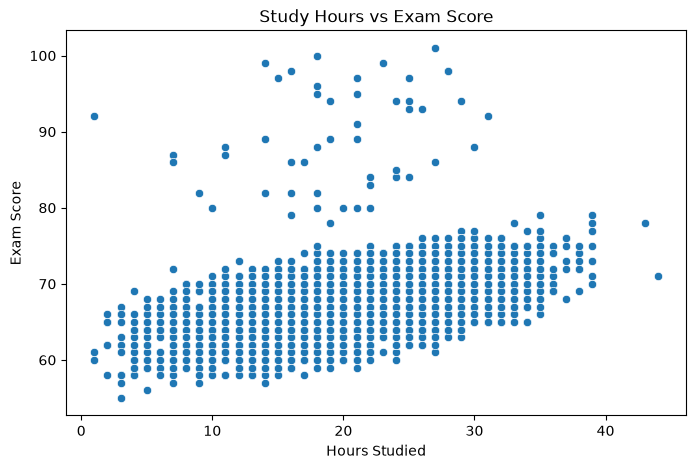

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

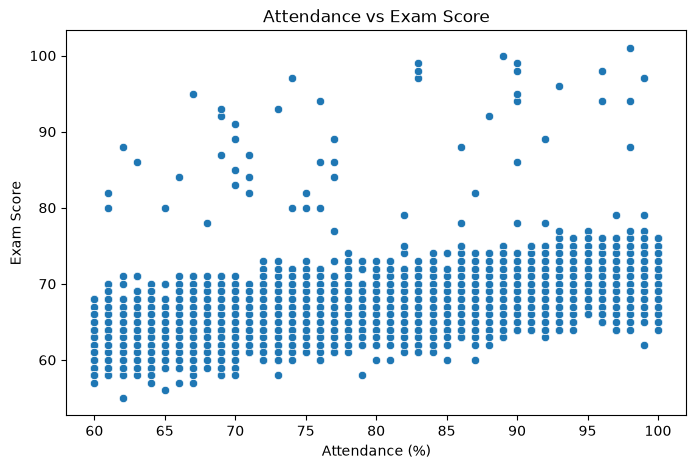

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")

plt.show()

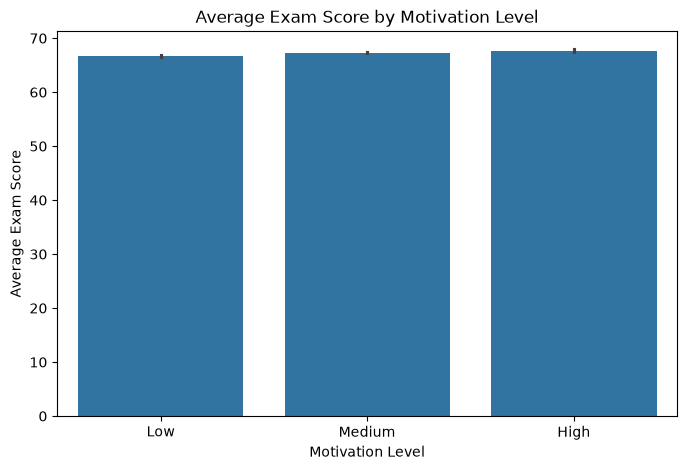

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Motivation_Level",
    y="Exam_Score"
)

plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")

plt.show()

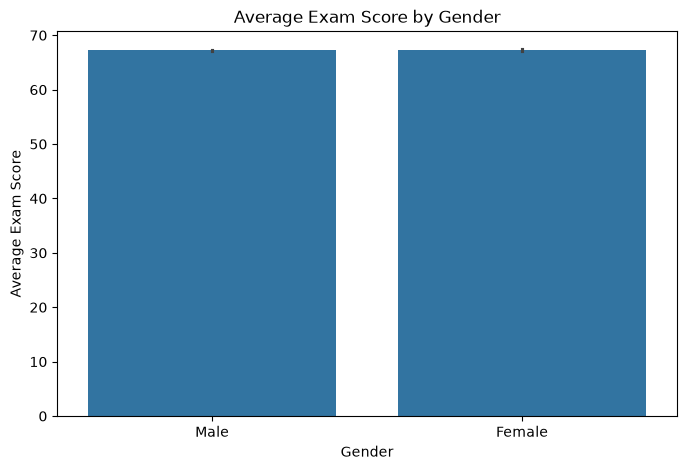

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Gender",
    y="Exam_Score"
)

plt.title("Average Exam Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Exam Score")

plt.show()

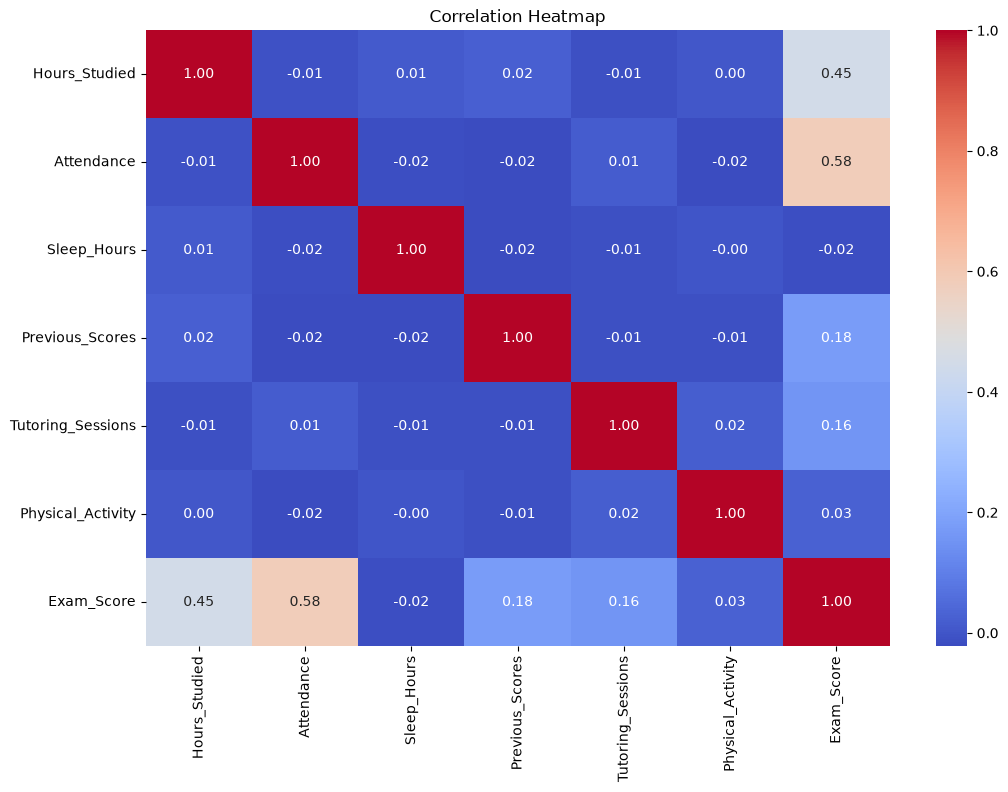

In [18]:
plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [20]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical Features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


C:\Users\Harini\AppData\Local\Temp\ipykernel_8136\3272322421.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5285
Testing samples: 1322


In [23]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5285, 19)
X_test : (1322, 19)
y_train: (5285,)
y_test : (1322,)


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression model created successfully!")

Linear Regression model created successfully!


In [25]:
linear_model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [26]:
y_pred = linear_model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[64.52628302 65.2651138  71.53126265 64.27748146 66.5216532  66.61246339
 72.47094891 66.49826901 69.98604472 70.13327106]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-------------------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

Model Evaluation
-------------------------
MAE  : 0.45
RMSE : 1.8
R²   : 0.77


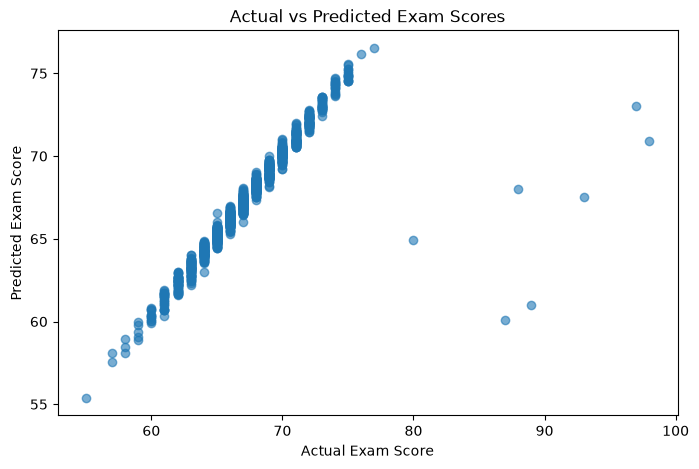

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

In [29]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]
)

decision_tree_model.fit(X_train, y_train)

dt_pred = decision_tree_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [31]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("----------------")
print("MAE  :", round(dt_mae, 2))
print("RMSE :", round(dt_rmse, 2))
print("R²   :", round(dt_r2, 2))

Decision Tree
----------------
MAE  : 1.75
RMSE : 3.54
R²   : 0.11


In [32]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [33]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("----------------")
print("MAE  :", round(rf_mae, 2))
print("RMSE :", round(rf_rmse, 2))
print("R²   :", round(rf_r2, 2))

Random Forest
----------------
MAE  : 1.08
RMSE : 2.16
R²   : 0.67


In [34]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.452392,1.804445,0.769650
1,Decision Tree,1.748865,3.539062,0.113909
2,Random Forest,1.079228,2.155993,0.671151


In [35]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("Best R² Score:", round(best_model["R2 Score"], 2))

Best Model: Linear Regression
Best R² Score: 0.77


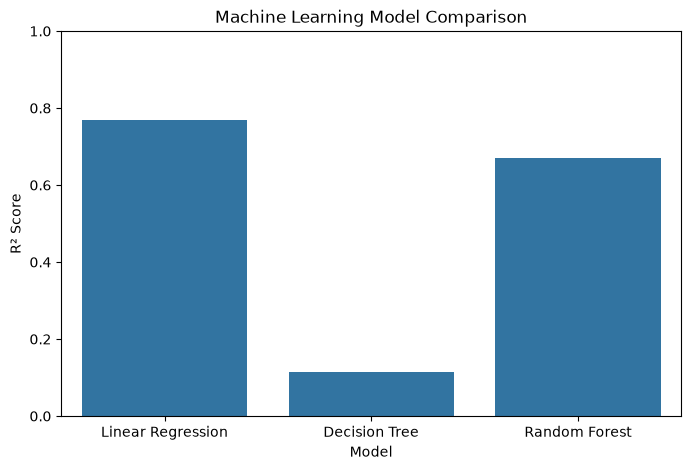

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.show()

In [37]:
print(df.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [38]:
new_student = pd.DataFrame({
    "Hours_Studied": [20],
    "Attendance": [85],
    "Parental_Involvement": ["High"],
    "Access_to_Resources": ["High"],
    "Extracurricular_Activities": ["Yes"],
    "Sleep_Hours": [7],
    "Previous_Scores": [75],
    "Motivation_Level": ["High"],
    "Internet_Access": ["Yes"],
    "Tutoring_Sessions": [2],
    "Family_Income": ["Medium"],
    "Teacher_Quality": ["High"],
    "School_Type": ["Public"],
    "Peer_Influence": ["Positive"],
    "Physical_Activity": [4],
    "Learning_Disabilities": ["No"],
    "Parental_Education_Level": ["College"],
    "Distance_from_Home": ["Near"],
    "Gender": ["Female"]
})

new_student

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,20,85,High,High,Yes,7,75,High,Yes,2,Medium,High,Public,Positive,4,No,College,Near,Female


In [39]:
predicted_score = random_forest_model.predict(new_student)

print("Predicted Exam Score:", round(predicted_score[0], 2))

Predicted Exam Score: 70.05


In [40]:
score = predicted_score[0]

print("==============================")
print(" STUDENT PERFORMANCE PREDICTION")
print("==============================")
print("Predicted Exam Score:", round(score, 2))

if score >= 90:
    print("Performance: Excellent")
elif score >= 75:
    print("Performance: Very Good")
elif score >= 60:
    print("Performance: Good")
elif score >= 40:
    print("Performance: Average")
else:
    print("Performance: Needs Improvement")

 STUDENT PERFORMANCE PREDICTION
Predicted Exam Score: 70.05
Performance: Good


In [41]:
all_predictions = random_forest_model.predict(X)

print("Predictions generated for all students!")
print("Number of predictions:", len(all_predictions))

Predictions generated for all students!
Number of predictions: 6607


In [42]:
powerbi_df = df.copy()

powerbi_df["Predicted_Score"] = all_predictions

powerbi_df["Prediction_Error"] = (
    powerbi_df["Exam_Score"] - powerbi_df["Predicted_Score"]
)

powerbi_df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Predicted_Score,Prediction_Error
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Public,Positive,3,No,High School,Near,Male,67,67.95,-0.95
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Public,Negative,4,No,College,Moderate,Female,61,61.24,-0.24
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Public,Neutral,4,No,Postgraduate,Near,Male,74,73.52,0.48
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Public,Negative,4,No,High School,Moderate,Male,71,71.19,-0.19
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,College,Near,Female,70,69.72,0.28


In [43]:
def performance_category(score):
    if score >= 90:
        return "Excellent"
    elif score >= 75:
        return "Very Good"
    elif score >= 60:
        return "Good"
    elif score >= 40:
        return "Average"
    else:
        return "Needs Improvement"

powerbi_df["Performance_Category"] = powerbi_df["Exam_Score"].apply(
    performance_category
)

powerbi_df[["Exam_Score", "Predicted_Score", "Performance_Category"]].head()

,Exam_Score,Predicted_Score,Performance_Category
0,67,67.95,Good
1,61,61.24,Good
2,74,73.52,Good
3,71,71.19,Good
4,70,69.72,Good


In [44]:
powerbi_df.to_csv(
    "Student_Performance_PowerBI.csv",
    index=False
)

print("Power BI dataset created successfully!")

Power BI dataset created successfully!


In [45]:
print("Rows:", powerbi_df.shape[0])
print("Columns:", powerbi_df.shape[1])

Rows: 6607
Columns: 23


In [46]:
powerbi_df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Predicted_Score,Prediction_Error,Performance_Category
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Positive,3,No,High School,Near,Male,67,67.95,-0.95,Good
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Negative,4,No,College,Moderate,Female,61,61.24,-0.24,Good
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Neutral,4,No,Postgraduate,Near,Male,74,73.52,0.48,Good
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Negative,4,No,High School,Moderate,Male,71,71.19,-0.19,Good
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Neutral,4,No,College,Near,Female,70,69.72,0.28,Good


In [47]:
powerbi_df.isnull().sum().sum()

np.int64(0)